# Sensitivity Analysis
**Scop:** Demonstram ca rezultatele nu depind de alegerile arbitrare de threshold si fereastra forward

**Ce testam:** 3 threshold-uri x 3 ferestre forward = 9 combinatii

**Model:** Voting Ensemble (NB + LightGBM + RF)

**Metrica principala:** ROC AUC cu 95% Bootstrap CI

## 1. Import si Setup

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.naive_bayes        import GaussianNB
from sklearn.ensemble           import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing      import StandardScaler
from sklearn.metrics            import roc_auc_score
from sklearn.utils              import resample
import lightgbm as lgb

os.makedirs('data',  exist_ok=True)
os.makedirs('plots', exist_ok=True)

THRESHOLDS   = [0.03, 0.05, 0.07]
FORWARD_DAYS = [45, 60, 90]
N_BOOTSTRAP  = 1000

EVENTS = [
    {'name': 'Dotcom Crash',           'start': '2000-01-01', 'end': '2002-10-31'},
    {'name': 'Global Financial Crisis','start': '2008-01-01', 'end': '2009-06-30'},
    {'name': 'European Debt Crisis',   'start': '2011-04-01', 'end': '2011-12-31'},
    {'name': 'Taper Tantrum',          'start': '2013-04-01', 'end': '2013-10-31'},
    {'name': 'China Devaluation',      'start': '2015-06-01', 'end': '2016-02-28'},
    {'name': 'Fed Rate Hikes 2022',    'start': '2022-01-01', 'end': '2022-12-31'},
    {'name': 'Liberation Day Tariffs', 'start': '2025-02-01', 'end': '2025-08-01'},
    {'name': 'COVID Crash',            'start': '2020-01-15', 'end': '2020-08-31'},
    {'name': '9/11',                   'start': '2001-07-01', 'end': '2001-12-31'},
    {'name': 'Flash Crash',            'start': '2010-04-01', 'end': '2010-08-31'},
]

TRAIN_EVENTS = [
    'Global Financial Crisis', 'European Debt Crisis',
    'Taper Tantrum', 'China Devaluation', '9/11', 'Flash Crash'
]
TEST_EVENTS = [
    'Fed Rate Hikes 2022', 'COVID Crash', 'Liberation Day Tariffs'
]

print('Setup complet.')
print('Combinatii totale:', len(THRESHOLDS) * len(FORWARD_DAYS))

Setup complet.
Combinatii totale: 9


## 2. Descarcare Date

In [2]:
sp500_raw = yf.download('^GSPC', start='1999-01-01', end='2025-09-01', auto_adjust=True)
sp500_raw = sp500_raw[['Close', 'Volume']].copy()
sp500_raw.columns = ['SP500_Close', 'SP500_Volume']

vix_raw = yf.download('^VIX', start='1999-01-01', end='2025-09-01', auto_adjust=True)
vix_raw = vix_raw[['Close']].copy()
vix_raw.columns = ['VIX_raw']

market_data = sp500_raw.join(vix_raw, how='left')
market_data.index = pd.to_datetime(market_data.index)

print('Date descarcate:', market_data.index[0].date(), '->', market_data.index[-1].date())
print('Total zile:', len(market_data))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Date descarcate: 1999-01-04 -> 2025-08-29
Total zile: 6706


## 3. Functii Helper

In [3]:
FEATURE_COLS = [
    'Return_1w', 'Return_4w', 'Dist_MA50', 'Dist_MA200',
    'Dist_Local_Min', 'VIX', 'VIX_Ratio', 'VIX_Trend_20d',
    'Volume_Ratio', 'RSI', 'SP500_Trend_20d', 'Phase'
]

def compute_features(data):
    df = data.copy()
    df['MA50']             = df['SP500_Close'].rolling(50).mean()
    df['MA200']            = df['SP500_Close'].rolling(200).mean()
    df['Dist_MA50']        = (df['SP500_Close'] - df['MA50'])  / df['MA50']
    df['Dist_MA200']       = (df['SP500_Close'] - df['MA200']) / df['MA200']
    df['Return_1d']        = df['SP500_Close'].pct_change()
    df['Realized_Vol_10d'] = df['Return_1d'].rolling(10).std() * np.sqrt(252)
    df['Local_Min_20d']    = df['SP500_Close'].rolling(20).min()
    df['Dist_Local_Min']   = (df['SP500_Close'] - df['Local_Min_20d']) / df['Local_Min_20d']
    df['VIX_MA60']         = df['VIX_raw'].rolling(60).mean()
    df['VIX_Ratio']        = df['VIX_raw'] / df['VIX_MA60']

    delta = df['SP500_Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    df['RSI'] = 100 - (100 / (1 + gain / loss))

    def rolling_slope(series, window):
        slopes = [np.nan] * len(series)
        vals, x = series.values, np.arange(window)
        for i in range(window - 1, len(vals)):
            y = vals[i - window + 1 : i + 1]
            if not np.any(np.isnan(y)):
                slopes[i] = np.polyfit(x, y, 1)[0]
        return pd.Series(slopes, index=series.index)

    df['VIX_Trend_20d']   = rolling_slope(df['VIX_raw'], 20)
    df['SP500_Trend_20d'] = rolling_slope(df['SP500_Close'], 20)
    return df


def build_dataset(market_data, threshold, forward_days):
    df = compute_features(market_data)
    df['Forward_Return'] = df['SP500_Close'].shift(-forward_days) / df['SP500_Close'] - 1
    df['label_daily']    = (df['Forward_Return'] > threshold).astype(float)

    agg_rules = {
        'SP500_Close'     : 'last',
        'SP500_Volume'    : 'sum',
        'VIX_raw'         : 'mean',
        'Dist_MA50'       : 'last',
        'Dist_MA200'      : 'last',
        'Dist_Local_Min'  : 'last',
        'VIX_Ratio'       : 'mean',
        'VIX_Trend_20d'   : 'mean',
        'SP500_Trend_20d' : 'last',
        'Realized_Vol_10d': 'mean',
        'RSI'             : 'last',
        'label_daily'     : lambda x: x.mode()[0] if len(x) > 0 else np.nan
    }

    weekly = df.resample('W-FRI').agg(agg_rules)
    weekly = weekly.rename(columns={'VIX_raw': 'VIX'})
    weekly['Return_1w']    = weekly['SP500_Close'].pct_change()
    weekly['Return_4w']    = weekly['SP500_Close'].pct_change(4)
    weekly['Volume_Ratio'] = weekly['SP500_Volume'] / weekly['SP500_Volume'].rolling(8).mean()
    weekly['label']        = weekly['label_daily'].astype(int)
    weekly = weekly.loc[:, ~weekly.columns.duplicated()]
    weekly.dropna(subset=['Return_1w', 'label'], inplace=True)

    all_windows = []
    for event in EVENTS:
        mask   = (weekly.index >= event['start']) & (weekly.index <= event['end'])
        window = weekly.loc[mask].copy()
        if len(window) == 0:
            continue
        n = len(window)
        window['Phase']      = [1 if i <= 6 else (2 if i <= 18 else 3) for i in range(n)]
        window['event_name'] = event['name']
        all_windows.append(window)

    dataset = pd.concat(all_windows).dropna(subset=FEATURE_COLS + ['label'])

    dotcom_all   = dataset[dataset['event_name'] == 'Dotcom Crash']
    dotcom_train = dotcom_all.iloc[:-40]
    dotcom_test  = dotcom_all.iloc[-40:]

    train = pd.concat([dotcom_train, dataset[dataset['event_name'].isin(TRAIN_EVENTS)]]).dropna(subset=FEATURE_COLS)
    test  = pd.concat([dotcom_test,  dataset[dataset['event_name'].isin(TEST_EVENTS)]]).dropna(subset=FEATURE_COLS)

    return train, test


def train_and_evaluate(train, test):
    X_train = train[FEATURE_COLS]
    y_train = train['label']
    X_test  = test[FEATURE_COLS]
    y_test  = test['label']

    scaler = StandardScaler()
    Xtr    = scaler.fit_transform(X_train)
    Xte    = scaler.transform(X_test)

    nb  = GaussianNB()
    rf  = RandomForestClassifier(n_estimators=200, max_depth=5,
                                 class_weight='balanced', random_state=42)
    lgbm = lgb.LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                               is_unbalance=True, random_state=42, verbose=-1)

    ensemble = VotingClassifier(
        estimators=[('nb', nb), ('rf', rf), ('lgb', lgbm)],
        voting='soft'
    )
    ensemble.fit(Xtr, y_train)
    y_proba = ensemble.predict_proba(Xte)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)

    boot_aucs = []
    for i in range(N_BOOTSTRAP):
        Xb, yb = resample(Xte, y_test, random_state=i)
        if len(np.unique(yb)) < 2:
            continue
        boot_aucs.append(roc_auc_score(yb, ensemble.predict_proba(Xb)[:, 1]))

    ci_low  = np.percentile(boot_aucs, 2.5)
    ci_high = np.percentile(boot_aucs, 97.5)
    v_pct   = round(test['label'].mean() * 100, 1)

    return auc, ci_low, ci_high, v_pct


print('Functii helper definite.')

Functii helper definite.


## 4. Rulare Sensitivity Analysis (9 combinatii)

In [4]:
results = []
total   = len(THRESHOLDS) * len(FORWARD_DAYS)
count   = 0

for threshold in THRESHOLDS:
    for forward in FORWARD_DAYS:
        count += 1
        label = 'T=' + str(int(threshold*100)) + '%, F=' + str(forward) + 'd'
        print('(' + str(count) + '/' + str(total) + ') ' + label + ' ...', end=' ', flush=True)

        try:
            train, test = build_dataset(market_data, threshold, forward)
            auc, ci_low, ci_high, v_pct = train_and_evaluate(train, test)

            results.append({
                'Threshold': str(int(threshold*100)) + '%',
                'Forward'  : str(forward) + 'd',
                'V_pct'    : v_pct,
                'AUC'      : round(auc, 3),
                'CI_low'   : round(ci_low, 3),
                'CI_high'  : round(ci_high, 3),
                'CI_width' : round(ci_high - ci_low, 3)
            })
            print('AUC=' + str(round(auc, 3)) +
                  ' [' + str(round(ci_low, 3)) + ', ' + str(round(ci_high, 3)) + ']')

        except Exception as e:
            print('EROARE:', e)
            results.append({
                'Threshold': str(int(threshold*100)) + '%',
                'Forward'  : str(forward) + 'd',
                'V_pct': np.nan, 'AUC': np.nan,
                'CI_low': np.nan, 'CI_high': np.nan, 'CI_width': np.nan
            })

results_df = pd.DataFrame(results)
results_df.to_csv('data/sensitivity_results.csv', index=False)
print('\nRezultate salvate: data/sensitivity_results.csv')
print(results_df.to_string(index=False))

(1/9) T=3%, F=45d ... AUC=0.685 [0.598, 0.772]
(2/9) T=3%, F=60d ... AUC=0.767 [0.686, 0.84]
(3/9) T=3%, F=90d ... AUC=0.685 [0.595, 0.773]
(4/9) T=5%, F=45d ... AUC=0.727 [0.635, 0.815]
(5/9) T=5%, F=60d ... AUC=0.777 [0.695, 0.849]
(6/9) T=5%, F=90d ... AUC=0.752 [0.667, 0.835]
(7/9) T=7%, F=45d ... AUC=0.699 [0.599, 0.8]
(8/9) T=7%, F=60d ... AUC=0.726 [0.638, 0.813]
(9/9) T=7%, F=90d ... AUC=0.728 [0.622, 0.814]

Rezultate salvate: data/sensitivity_results.csv
Threshold Forward  V_pct   AUC  CI_low  CI_high  CI_width
       3%     45d   38.4 0.685   0.598    0.772     0.174
       3%     60d   37.1 0.767   0.686    0.840     0.154
       3%     90d   33.8 0.685   0.595    0.773     0.178
       5%     45d   27.8 0.727   0.635    0.815     0.180
       5%     60d   31.1 0.777   0.695    0.849     0.154
       5%     90d   28.5 0.752   0.667    0.835     0.169
       7%     45d   19.2 0.699   0.599    0.800     0.201
       7%     60d   24.5 0.726   0.638    0.813     0.175
       7%

## 5. Heatmap AUC per Combinatie

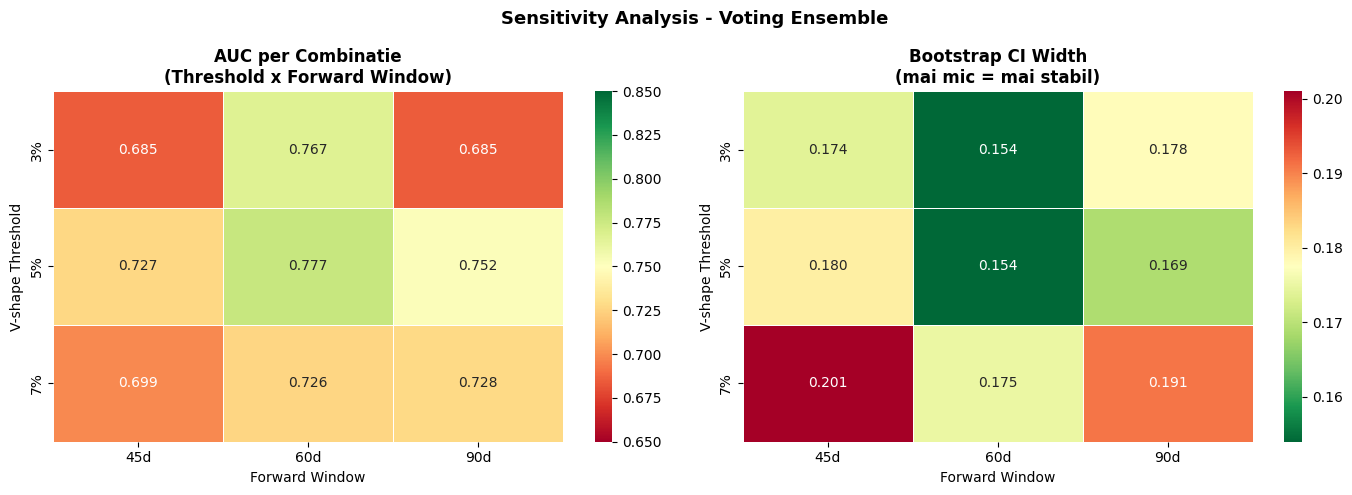

Salvat: plots/sensitivity_heatmap.png


In [5]:
pivot_auc = results_df.pivot(index='Threshold', columns='Forward', values='AUC')
pivot_ci  = results_df.pivot(index='Threshold', columns='Forward', values='CI_width')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    pivot_auc, annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0.65, vmax=0.85,
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title('AUC per Combinatie\n(Threshold x Forward Window)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Forward Window')
axes[0].set_ylabel('V-shape Threshold')

sns.heatmap(
    pivot_ci, annot=True, fmt='.3f',
    cmap='RdYlGn_r', linewidths=0.5, ax=axes[1]
)
axes[1].set_title('Bootstrap CI Width\n(mai mic = mai stabil)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Forward Window')
axes[1].set_ylabel('V-shape Threshold')

plt.suptitle('Sensitivity Analysis - Voting Ensemble', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/sensitivity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/sensitivity_heatmap.png')

## 6. AUC cu Confidence Intervals

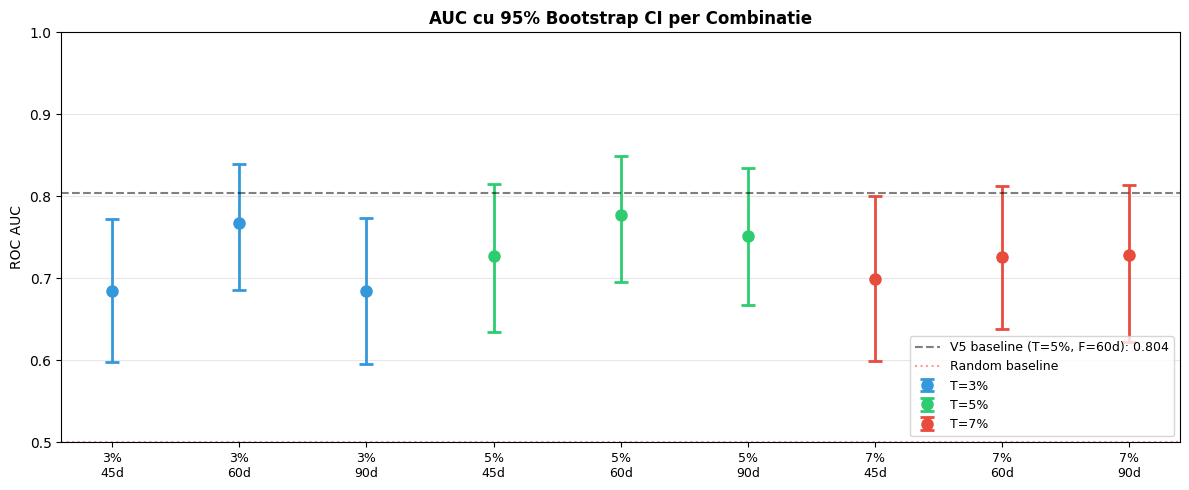

Salvat: plots/sensitivity_ci_plot.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
colors_thresh = {'3%': '#3498db', '5%': '#2ecc71', '7%': '#e74c3c'}
seen = set()

for i, row in results_df.iterrows():
    color = colors_thresh.get(row['Threshold'], '#95a5a6')
    label = 'T=' + row['Threshold'] if row['Threshold'] not in seen else None
    seen.add(row['Threshold'])

    ax.errorbar(
        x=i, y=row['AUC'],
        yerr=[[row['AUC'] - row['CI_low']], [row['CI_high'] - row['AUC']]],
        fmt='o', color=color, capsize=5, capthick=2,
        markersize=8, linewidth=2, label=label
    )

ax.axhline(0.804, color='black', linestyle='--', alpha=0.5,
           label='V5 baseline (T=5%, F=60d): 0.804')
ax.axhline(0.5, color='red', linestyle=':', alpha=0.4, label='Random baseline')

ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(
    [r['Threshold'] + '\n' + r['Forward'] for _, r in results_df.iterrows()],
    fontsize=9
)
ax.set_ylabel('ROC AUC')
ax.set_ylim(0.5, 1.0)
ax.set_title('AUC cu 95% Bootstrap CI per Combinatie', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/sensitivity_ci_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/sensitivity_ci_plot.png')

## 7. Rezumat si Concluzii

In [7]:
separator = '=' * 55
print('REZUMAT SENSITIVITY ANALYSIS')
print(separator)
print(results_df[['Threshold', 'Forward', 'V_pct', 'AUC', 'CI_low', 'CI_high']].to_string(index=False))
print()
print('Statistica AUC peste toate combinatiile:')
print('  Media:  ', round(results_df['AUC'].mean(), 3))
print('  Std:    ', round(results_df['AUC'].std(), 3))
print('  Min:    ', round(results_df['AUC'].min(), 3))
print('  Max:    ', round(results_df['AUC'].max(), 3))
print('  Range:  ', round(results_df['AUC'].max() - results_df['AUC'].min(), 3))
print()

auc_std = results_df['AUC'].std()
if auc_std < 0.03:
    print('CONCLUZIE: Rezultatele sunt ROBUSTE.')
    print('Variatia AUC sub 0.03 intre toate combinatiile.')
    print('Alegerea threshold-ului si ferestrei forward nu afecteaza semnificativ performanta.')
elif auc_std < 0.06:
    print('CONCLUZIE: Rezultatele sunt MODERAT ROBUSTE.')
    print('Variatia AUC intre 0.03-0.06. Specificati alegerea optima in paper.')
else:
    print('ATENTIE: Variatia AUC este RIDICATA (>0.06).')
    print('Rezultatele depind sensibil de alegerea parametrilor.')

REZUMAT SENSITIVITY ANALYSIS
Threshold Forward  V_pct   AUC  CI_low  CI_high
       3%     45d   38.4 0.685   0.598    0.772
       3%     60d   37.1 0.767   0.686    0.840
       3%     90d   33.8 0.685   0.595    0.773
       5%     45d   27.8 0.727   0.635    0.815
       5%     60d   31.1 0.777   0.695    0.849
       5%     90d   28.5 0.752   0.667    0.835
       7%     45d   19.2 0.699   0.599    0.800
       7%     60d   24.5 0.726   0.638    0.813
       7%     90d   26.5 0.728   0.622    0.814

Statistica AUC peste toate combinatiile:
  Media:   0.727
  Std:     0.034
  Min:     0.685
  Max:     0.777
  Range:   0.092

CONCLUZIE: Rezultatele sunt MODERAT ROBUSTE.
Variatia AUC intre 0.03-0.06. Specificati alegerea optima in paper.
